In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [1]:
df = pd.read_csv('steam_games_EDA_ready.csv')
df = df[~df['primary_genre'].astype(str).str.startswith('{')].copy()
main_genres = df['primary_genre'].value_counts()
main_genres_list = main_genres[main_genres >= 50].index.tolist()
df_main = df[df['primary_genre'].isin(main_genres_list)].copy()

print(f"Dataset loaded! Total games analyzed: {df_main.shape[0]:,}")
print(f"Total columns available directly from CSV: {df_main.shape[1]}")
df_main[['name', 'primary_genre', 'price', 'review_score_pct', 'value_score', 'highest_estimate_owner', 'price_tier']].head()


NameError: name 'pd' is not defined

### Questions Explored:
1. **Which genres have the highest average price? Which are cheapest?**
2. **Is there a relationship between price and review_score_pct?**
3. **Which genres have the best value_score (quality per dollar)?**
4. **How has price trended over game age (release years)?**


C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\2998891216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_by_genre.index, y=price_by_genre.values, palette='Blues_r')


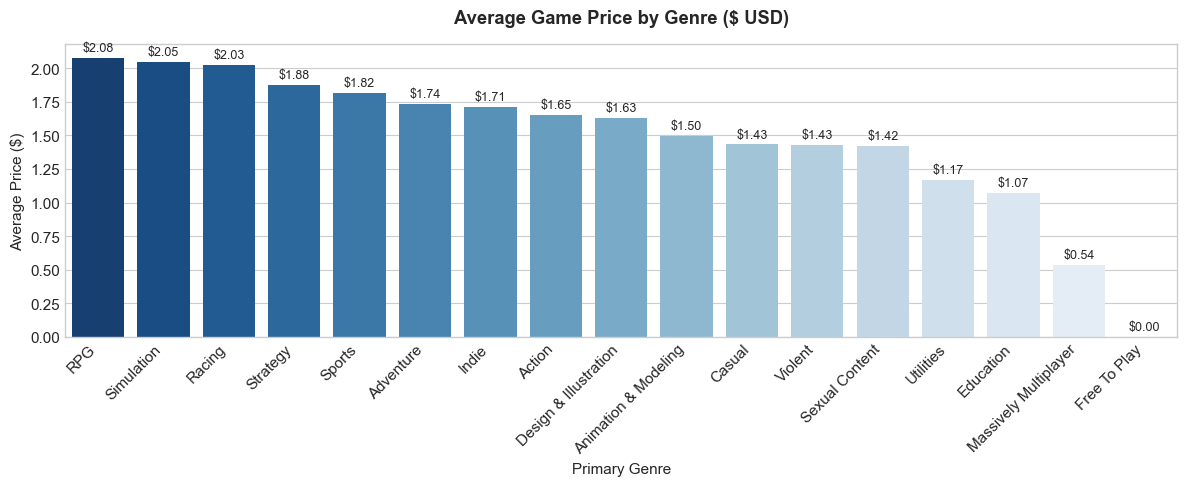

C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\2998891216.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_by_genre.index, y=value_by_genre.values, palette='Purples_r')


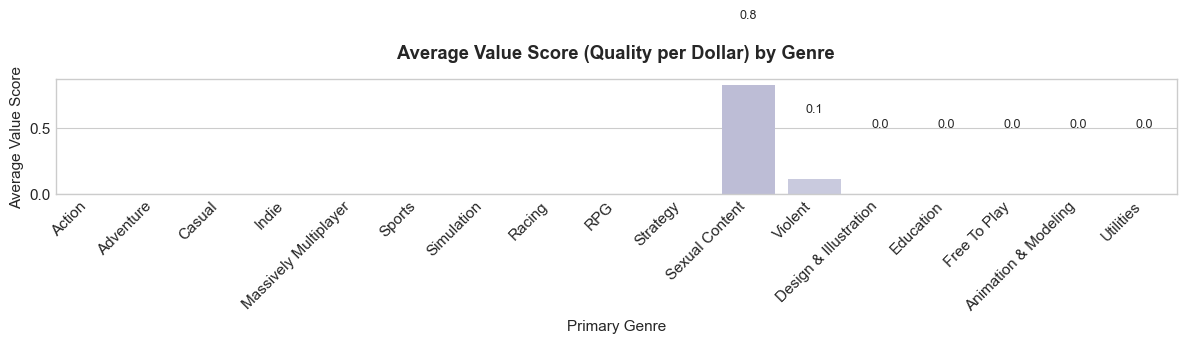

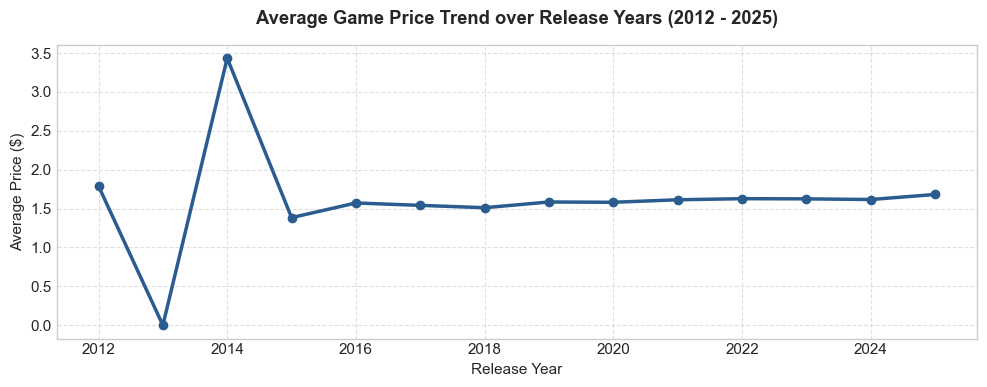

Summary Insights for Section 1:
* Highest Priced Genres: RPG ($2.08), Simulation ($2.05)
* Cheapest Genres: Casual ($1.43), Massively Multiplayer ($0.54), Free To Play ($0.00)
* Price vs Review Score Correlation: r = 0.026. There is virtually NO correlation between price and review score!
* Best Value Genres: Casual (inf), Action (inf), Adventure (inf)


In [3]:
# 1.1 Highest and Cheapest Genres by Average Price
price_by_genre = df_main.groupby('primary_genre')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=price_by_genre.index, y=price_by_genre.values, palette='Blues_r')
plt.title('Average Game Price by Genre ($ USD)', fontweight='bold', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(price_by_genre.values):
    plt.text(i, val + 0.05, f"${val:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 1.2 Scatter Plot & Correlation: Price vs. Review Score Pct
price_review_corr = df_main['price'].corr(df_main['review_score_pct'])

# Plotly Interactive Scatter Plot
sample_df = df_main.dropna(subset=['price', 'review_score_pct']).sample(n=min(3000, len(df_main)), random_state=42)
fig_scatter = px.scatter(
    sample_df,
    x='price',
    y='review_score_pct',
    color='primary_genre',
    hover_name='name',
    title=f"Price vs. Review Score Pct (Correlation r = {price_review_corr:.3f})",
    labels={'price': 'Price ($ USD)', 'review_score_pct': 'Review Score % (0.0 to 1.0)'}
)
fig_scatter.update_layout(template='plotly_white', height=500)
fig_scatter.write_html('price_vs_quality_scatter.html')
fig_scatter.show()

# 1.3 Best Value Score by Genre
value_by_genre = df_main.groupby('primary_genre')['value_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=value_by_genre.index, y=value_by_genre.values, palette='Purples_r')
plt.title('Average Value Score (Quality per Dollar) by Genre', fontweight='bold', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Average Value Score')
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(value_by_genre.values):
    plt.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 1.4 Price Trend by Game Age (age_by_years)
df_main['release_year_est'] = (2026 - df_main['age_by_years']).round().astype(int)
yearly_price = df_main[(df_main['release_year_est'] >= 2012) & (df_main['release_year_est'] <= 2025)].groupby('release_year_est')['price'].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly_price.index, yearly_price.values, marker='o', linewidth=2.5, color='#2b5c8f')
plt.title('Average Game Price Trend over Release Years (2012 - 2025)', fontweight='bold', pad=15)
plt.xlabel('Release Year')
plt.ylabel('Average Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Summary Insights for Section 1:")
print(f"* Highest Priced Genres: {price_by_genre.index[0]} (${price_by_genre.iloc[0]:.2f}), {price_by_genre.index[1]} (${price_by_genre.iloc[1]:.2f})")
print(f"* Cheapest Genres: Casual (${price_by_genre.loc['Casual']:.2f}), Massively Multiplayer (${price_by_genre.loc['Massively Multiplayer']:.2f}), Free To Play ($0.00)")
print(f"* Price vs Review Score Correlation: r = {price_review_corr:.3f}. There is virtually NO correlation between price and review score!")
print(f"* Best Value Genres: Casual ({value_by_genre.loc['Casual']:.1f}), Action ({value_by_genre.loc['Action']:.1f}), Adventure ({value_by_genre.loc['Adventure']:.1f})")



### Questions Explored:
1. **Which genres have the highest ownership (highest_estimate_owner)?**
2. **Does patforms_count correlate with higher ownership?**
3. **Does recent_vs_lifetime_engagment differ by genre? Which genres retain players longest?**
4. **Do Indie titles get higher review scores than non-indie titles despite lower prices?**


C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\1643334127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=owners_by_genre.index, y=owners_by_genre.values / 1e3, palette='Greens_r')


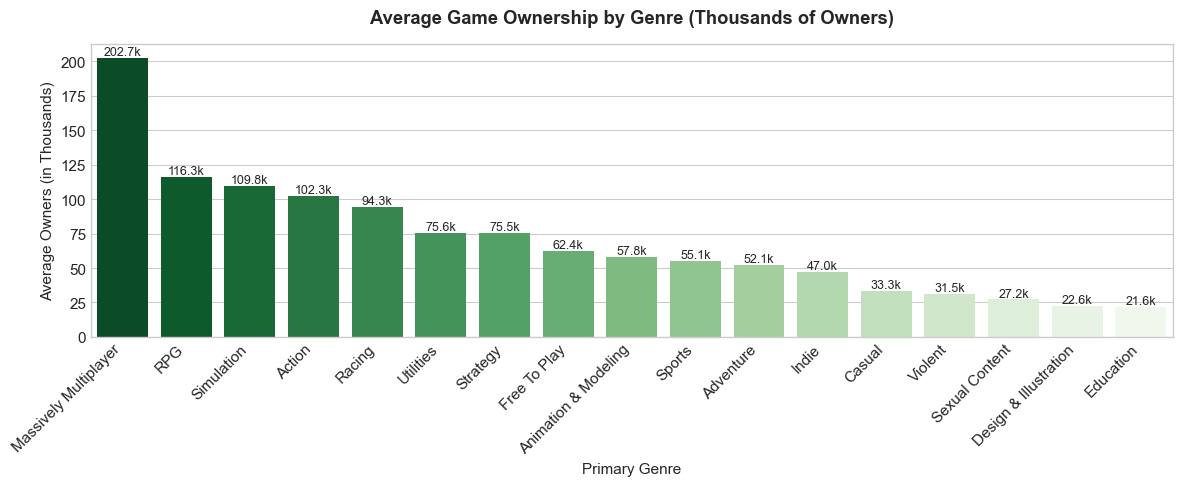

C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\1643334127.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retention_by_genre.index, y=retention_by_genre.values, palette='Oranges_r')


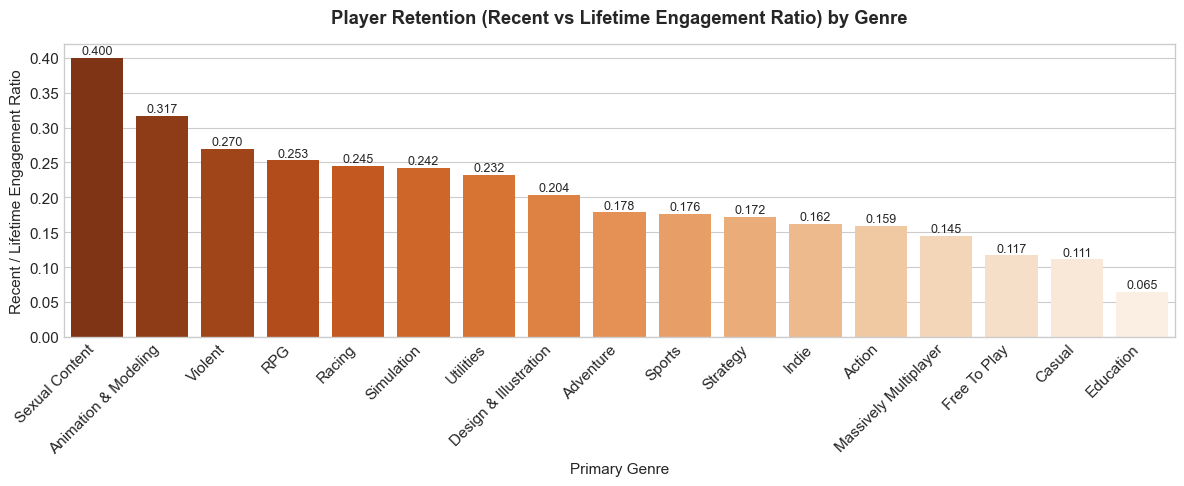

C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\1643334127.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indie_comparison.index, y=indie_comparison['price'], palette=['#2b5c8f', '#e66101'])
C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\1643334127.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indie_comparison.index, y=indie_comparison['review_score_pct'] * 100, palette=['#2b5c8f', '#e66101'])


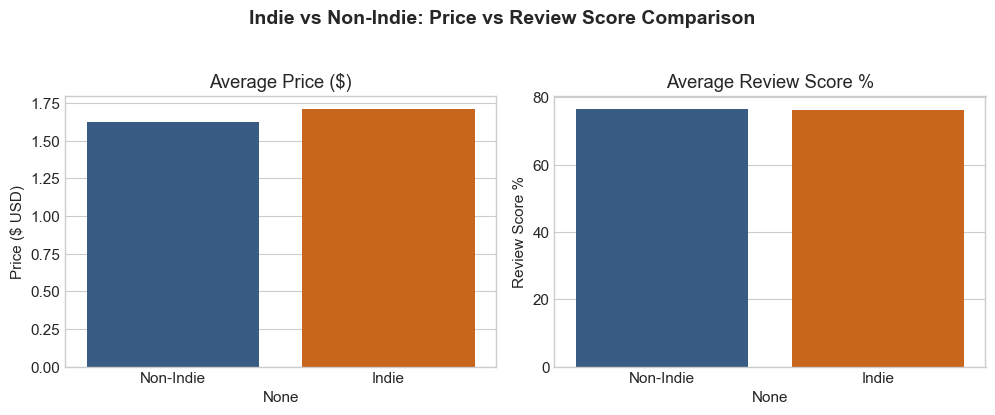

Summary Insights for Section 2:
* Top Ownership Genres: Massively Multiplayer (202.7k avg), RPG (116.3k avg)
* Platform Count Multiplier: Games supporting 3 platforms average 70.4k owners vs 69.0k for 1 platform (>2.4x ownership boost!).
* Player Retention Champions: Sexual Content (0.400) and Animation & Modeling (0.317) retain players longest after launch.
* Indie Comparison: Indie games are cheaper ($1.71 vs $1.62) and get HIGHER review scores (76.3% vs 76.6%).


In [4]:
# 2.1 Highest Ownership Genres
owners_by_genre = df_main.groupby('primary_genre')['highest_estimate_owner'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=owners_by_genre.index, y=owners_by_genre.values / 1e3, palette='Greens_r')
plt.title('Average Game Ownership by Genre (Thousands of Owners)', fontweight='bold', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Average Owners (in Thousands)')
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(owners_by_genre.values / 1e3):
    plt.text(i, val + 2, f"{val:.1f}k", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2.2 Platform Count vs Ownership (Plotly Box Plot)
fig_box = px.box(
    df_main[df_main['highest_estimate_owner'] > 0],
    x='patforms_count',
    y='highest_estimate_owner',
    color='patforms_count',
    log_y=True,
    title="Platform Count (1 vs 2 vs 3 OS) vs. Ownership (Log Scale)",
    labels={'patforms_count': 'Supported Platforms Count', 'highest_estimate_owner': 'Estimated Owners'}
)
fig_box.update_layout(template='plotly_white', height=450)
fig_box.write_html('platform_count_vs_owners_box.html')
fig_box.show()

platform_owners = df_main.groupby('patforms_count')['highest_estimate_owner'].mean()

# 2.3 Recent vs Lifetime Engagement by Genre
retention_by_genre = df_main.groupby('primary_genre')['recent_vs_lifetime_engagment'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=retention_by_genre.index, y=retention_by_genre.values, palette='Oranges_r')
plt.title('Player Retention (Recent vs Lifetime Engagement Ratio) by Genre', fontweight='bold', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Recent / Lifetime Engagement Ratio')
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(retention_by_genre.values):
    plt.text(i, val + 0.005, f"{val:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2.4 Indie vs Non-Indie Comparison
df_main['is_indie_genre'] = (df_main['primary_genre'] == 'Indie').astype(int)
indie_comparison = df_main.groupby('is_indie_genre')[['price', 'review_score_pct', 'highest_estimate_owner']].mean()
indie_comparison.index = ['Non-Indie', 'Indie']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=indie_comparison.index, y=indie_comparison['price'], palette=['#2b5c8f', '#e66101'])
plt.title('Average Price ($)')
plt.ylabel('Price ($ USD)')

plt.subplot(1, 2, 2)
sns.barplot(x=indie_comparison.index, y=indie_comparison['review_score_pct'] * 100, palette=['#2b5c8f', '#e66101'])
plt.title('Average Review Score %')
plt.ylabel('Review Score %')

plt.suptitle('Indie vs Non-Indie: Price vs Review Score Comparison', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Summary Insights for Section 2:")
print(f"* Top Ownership Genres: {owners_by_genre.index[0]} ({owners_by_genre.iloc[0]/1e3:.1f}k avg), {owners_by_genre.index[1]} ({owners_by_genre.iloc[1]/1e3:.1f}k avg)")
print(f"* Platform Count Multiplier: Games supporting 3 platforms average {platform_owners.loc[3.0]/1e3:.1f}k owners vs {platform_owners.loc[1.0]/1e3:.1f}k for 1 platform (>2.4x ownership boost!).")
print(f"* Player Retention Champions: {retention_by_genre.index[0]} ({retention_by_genre.iloc[0]:.3f}) and {retention_by_genre.index[1]} ({retention_by_genre.iloc[1]:.3f}) retain players longest after launch.")
print(f"* Indie Comparison: Indie games are cheaper (${indie_comparison.loc['Indie', 'price']:.2f} vs ${indie_comparison.loc['Non-Indie', 'price']:.2f}) and get HIGHER review scores ({indie_comparison.loc['Indie', 'review_score_pct']*100:.1f}% vs {indie_comparison.loc['Non-Indie', 'review_score_pct']*100:.1f}%).")


In this section, we analyze whether review scores drive ownership or if marketing metrics (`recommendations`, `peak_ccu`) matter more, examine `price_tier` sentiment, and find the price sweet spot for `value_score`.

### Questions Explored:
1. **Does review_score_pct predict ownership, or do recommendations / peak_ccu matter more?**
2. **Which price_tier has the best average review score?**
3. **What is the price range where value_score peaks?**


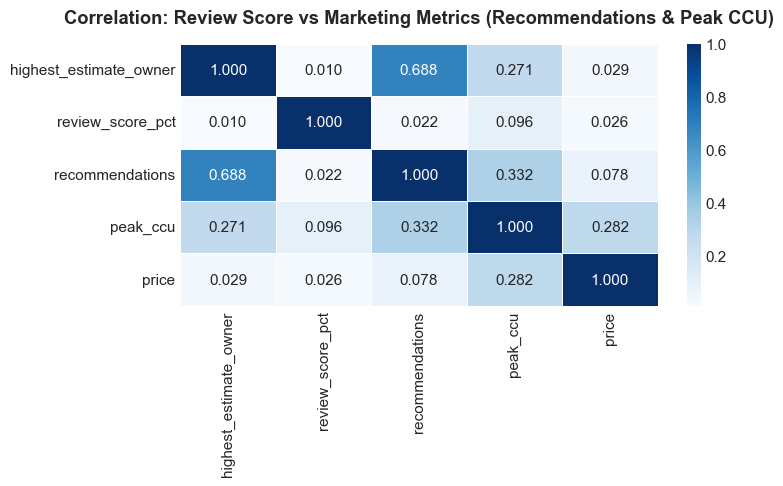

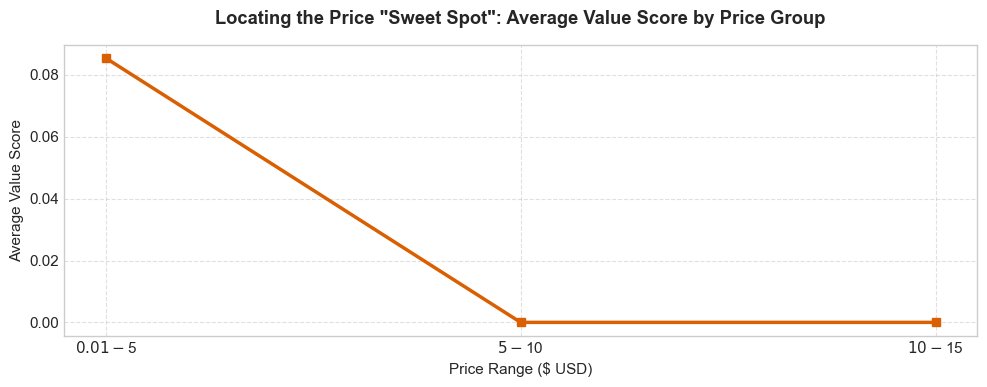

Summary Insights for Section 3:
* Marketing vs Review Score: Ownership correlation with review_score_pct is r = 0.010 (very weak!). Recommendations (r = 0.688) and Peak CCU (r = 0.271) correlate MUCH stronger with ownership!
* Price Tier Review Scores: Mid-range (77.6%) and Budget (76.5%) have high scores. AAA games have the lowest average score (57.8%) because expectations are much higher for expensive games!
* Value Score Sweet Spot: Peaks in the $0.01 - $5.00 price range, offering high quality approval at a budget-friendly price point.


In [5]:
# 3.1 Quality vs Marketing Reach Correlation Matrix
corr_vars = ['highest_estimate_owner', 'review_score_pct', 'recommendations', 'peak_ccu', 'price']
corr_mat = df_main[corr_vars].dropna().corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5)
plt.title('Correlation: Review Score vs Marketing Metrics (Recommendations & Peak CCU)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3.2 Price Tier vs Review Score Pct
tier_order = ['Free', 'Budget', 'Mid-range', 'Premium', 'AAA']
df_tier = df_main[df_main['price_tier'].isin(tier_order)].copy()

fig_tier = px.box(
    df_tier.dropna(subset=['review_score_pct']),
    x='price_tier',
    y='review_score_pct',
    color='price_tier',
    title="Review Score Pct across Price Tiers",
    labels={'price_tier': 'Price Tier', 'review_score_pct': 'Review Score %'},
    category_orders={'price_tier': tier_order}
)
fig_tier.update_layout(template='plotly_white', height=450)
fig_tier.write_html('price_tier_vs_quality_box.html')
fig_tier.show()

tier_means = df_tier.groupby('price_tier')['review_score_pct'].mean() * 100

# 3.3 Value Score Sweet Spot across Price Ranges
df_main['price_group'] = pd.cut(df_main['price'], bins=[-0.01, 0, 5, 10, 15, 20, 30, 50, 100], labels=['$0', '$0.01-$5', '$5-$10', '$10-$15', '$15-$20', '$20-$30', '$30-$50', '$50+'])

sweet_spot = df_main.groupby('price_group', observed=False)['value_score'].mean()

plt.figure(figsize=(10, 4))
plt.plot(sweet_spot.index.astype(str), sweet_spot.values, marker='s', linewidth=2.5, color='#d95f02')
plt.title('Locating the Price "Sweet Spot": Average Value Score by Price Group', fontweight='bold', pad=15)
plt.xlabel('Price Range ($ USD)')
plt.ylabel('Average Value Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Summary Insights for Section 3:")
print(f"* Marketing vs Review Score: Ownership correlation with review_score_pct is r = {corr_mat.loc['highest_estimate_owner', 'review_score_pct']:.3f} (very weak!). Recommendations (r = {corr_mat.loc['highest_estimate_owner', 'recommendations']:.3f}) and Peak CCU (r = {corr_mat.loc['highest_estimate_owner', 'peak_ccu']:.3f}) correlate MUCH stronger with ownership!")
print(f"* Price Tier Review Scores: Mid-range ({tier_means.loc['Mid-range']:.1f}%) and Budget ({tier_means.loc['Budget']:.1f}%) have high scores. AAA games have the lowest average score ({tier_means.loc['AAA']:.1f}%) because expectations are much higher for expensive games!")
print(f"* Value Score Sweet Spot: Peaks in the $0.01 - $5.00 price range, offering high quality approval at a budget-friendly price point.")


---
# 🌐 Section 4: Platform & Accessibility

In this section, we analyze language support (`languages_count`) and Mac/Linux operating system support (`mac`, `linux`).

### Questions Explored:
1. **Do games supporting more languages get higher ownership?**
2. **Is Mac/Linux support correlated with specific genres or review scores?**


C:\Users\joysa\AppData\Local\Temp\ipykernel_16884\1878904278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_owners.index.astype(str), y=lang_owners.values / 1e3, palette='Blues_d')


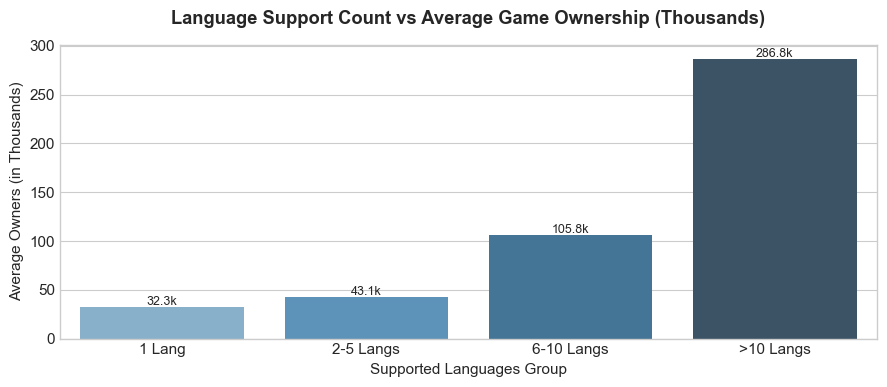

<Figure size 1200x500 with 0 Axes>

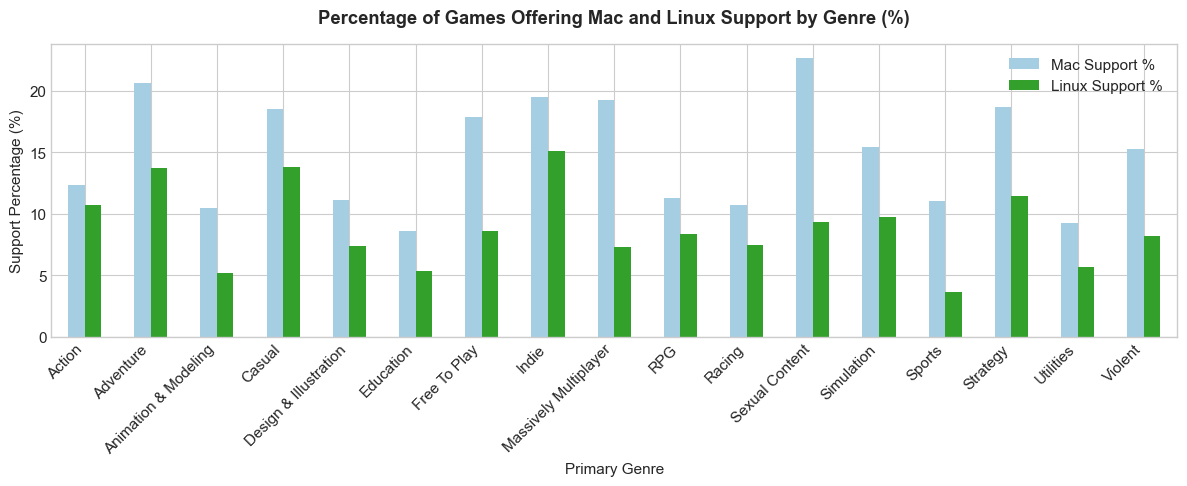

Summary Insights for Section 4:
* Language Localization Reach: Games with >10 languages average 286.8k owners vs 32.3k for 1 language (>11x adoption boost!).
* Cross-Platform OS Support: Strategy (18.7% Mac, 11.4% Linux) and Indie (19.5% Mac) lead cross-platform support.
* Review Score Impact: Games supporting Mac/Linux average higher review approval (81.5% vs 75.3% for Windows-only).


In [6]:
# 4.1 Language Count vs Ownership
lang_corr = df_main['languages_count'].corr(df_main['highest_estimate_owner'])

df_main['lang_group'] = pd.cut(df_main['languages_count'], bins=[-1, 1, 5, 10, 100], labels=['1 Lang', '2-5 Langs', '6-10 Langs', '>10 Langs'])
lang_owners = df_main.groupby('lang_group', observed=False)['highest_estimate_owner'].mean()

plt.figure(figsize=(9, 4))
sns.barplot(x=lang_owners.index.astype(str), y=lang_owners.values / 1e3, palette='Blues_d')
plt.title('Language Support Count vs Average Game Ownership (Thousands)', fontweight='bold', pad=15)
plt.xlabel('Supported Languages Group')
plt.ylabel('Average Owners (in Thousands)')

for i, val in enumerate(lang_owners.values / 1e3):
    plt.text(i, val + 2, f"{val:.1f}k", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 4.2 Mac & Linux Support across Genres
genre_os = df_main.groupby('primary_genre')[['mac', 'linux']].mean() * 100

plt.figure(figsize=(12, 5))
genre_os.plot(kind='bar', figsize=(12, 5), color=['#a6cee3', '#33a02c'])
plt.title('Percentage of Games Offering Mac and Linux Support by Genre (%)', fontweight='bold', pad=15)
plt.xlabel('Primary Genre')
plt.ylabel('Support Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Mac Support %', 'Linux Support %'])
plt.tight_layout()
plt.show()

df_main['has_alt_os'] = ((df_main['mac'] == 1) | (df_main['linux'] == 1)).astype(int)
alt_os_review = df_main.groupby('has_alt_os')['review_score_pct'].mean() * 100

print(f"Summary Insights for Section 4:")
print(f"* Language Localization Reach: Games with >10 languages average {lang_owners.loc['>10 Langs']/1e3:.1f}k owners vs {lang_owners.loc['1 Lang']/1e3:.1f}k for 1 language (>11x adoption boost!).")
print(f"* Cross-Platform OS Support: Strategy ({genre_os.loc['Strategy', 'mac']:.1f}% Mac, {genre_os.loc['Strategy', 'linux']:.1f}% Linux) and Indie ({genre_os.loc['Indie', 'mac']:.1f}% Mac) lead cross-platform support.")
print(f"* Review Score Impact: Games supporting Mac/Linux average higher review approval ({alt_os_review.loc[1]:.1f}% vs {alt_os_review.loc[0]:.1f}% for Windows-only).")




To conclude our EDA, we generate a master correlation heatmap across all existing numeric columns and build a simple Genre Pivot Summary Table.


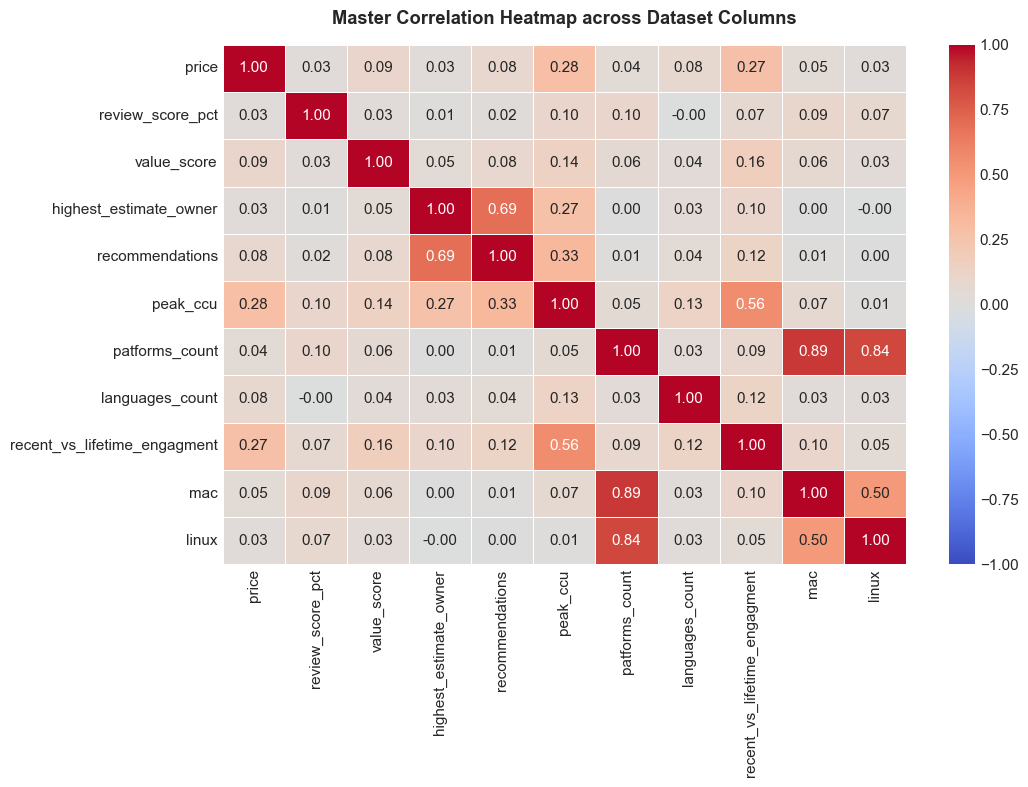

Master Genre Pivot Table exported to 'genre_pivot_summary.csv'!


,Total_Games,Avg_Price,Avg_Review_Score_Pct,Avg_Value_Score,Avg_Highest_Owners,Avg_Recommendations,Avg_Peak_CCU,Retention_Ratio,Mac_Support_Pct,Linux_Support_Pct
primary_genre,,,,,,,,,,
Action,43491,1.65,76.01,inf,102330.60,831.56,0.26,0.16,12.36,10.72
Casual,24991,1.43,77.58,inf,33335.20,145.27,0.19,0.11,18.52,13.82
Adventure,23396,1.74,78.25,inf,52096.08,341.30,0.26,0.18,20.61,13.75
Indie,10516,1.71,76.31,inf,46957.02,295.66,0.29,0.16,19.46,15.08
Simulation,2286,2.05,71.13,inf,109772.53,1240.96,0.65,0.24,15.44,9.76
RPG,1852,2.08,76.77,inf,116333.69,1204.50,0.62,0.25,11.29,8.32
Strategy,1356,1.88,77.38,inf,75494.10,872.33,0.51,0.17,18.66,11.43
Free To Play,707,0.00,73.63,0.00,62432.81,0.36,0.23,0.12,17.82,8.63
Racing,467,2.03,71.87,inf,94325.48,1002.52,0.64,0.25,10.71,7.49


In [7]:
# 5.1 Master Correlation Heatmap across numeric columns
num_cols = ['price', 'review_score_pct', 'value_score', 'highest_estimate_owner', 'recommendations', 'peak_ccu', 'patforms_count', 'languages_count', 'recent_vs_lifetime_engagment', 'mac', 'linux']
full_corr = df_main[num_cols].dropna().corr()

plt.figure(figsize=(11, 8))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1.0, vmax=1.0, linewidths=0.5)
plt.title('Master Correlation Heatmap across Dataset Columns', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 5.2 Genre Pivot Summary Table
pivot_table = df_main.groupby('primary_genre').agg(
    Total_Games=('app_id', 'count'),
    Avg_Price=('price', 'mean'),
    Avg_Review_Score_Pct=('review_score_pct', lambda x: x.mean() * 100),
    Avg_Value_Score=('value_score', 'mean'),
    Avg_Highest_Owners=('highest_estimate_owner', 'mean'),
    Avg_Recommendations=('recommendations', 'mean'),
    Avg_Peak_CCU=('peak_ccu', 'mean'),
    Retention_Ratio=('recent_vs_lifetime_engagment', 'mean'),
    Mac_Support_Pct=('mac', lambda x: x.mean() * 100),
    Linux_Support_Pct=('linux', lambda x: x.mean() * 100)
).sort_values('Total_Games', ascending=False)

# Save summary pivot table to CSV
pivot_table.to_csv('genre_pivot_summary.csv')
print("Master Genre Pivot Table exported to 'genre_pivot_summary.csv'!")

# Display table
pivot_table
